In [ ]:
%cd ../.
import sys
# sys.path.append('../keys'); # sys.path.append('./.')

In [47]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem,rdFMCS
import prolif as plf
from glob import glob
import meeko
import subprocess as sub
from vina import Vina
import time
from sklearn.ensemble import RandomForestClassifier

# user defined modules
import python.Rdkit_tools as rdkit_tools
import python.Molecule as M
import python.ML_Reg as ML_Reg
import python.ML_Class as ML_Class
from python.MolViz3D import MolViz3D
# from tdc.multi_pred import DTI

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
%%time
data = DTI(name='DAVIS').get_data()  # columns: Drug (SMILES), Target (AA seq), Y (Kd nM), + IDs

In [63]:
dataset = data[['Drug_ID','Drug', 'Target', 'Y']].rename(columns={'Drug_ID':'compound','Drug': 'smiles', 'Target': 'protein', 'Y': 'label'})
dataset = dataset.groupby('compound').first().reset_index().drop('protein', axis=1)  # drop duplicates (same compound with different targets)
dataset['compound'] = 'XX' + dataset['compound'].astype(str)
dataset['label'] = dataset['label'].apply(lambda x: 1 if x < 2500 else 0)  # binarize labels: 1 if Kd < 100 nM, else 0
dataset['label'].sum()

23

In [106]:
%%time
## get MF bits for all compounds in dataset
properties = rdkit_tools.compute_properties_from_smiles(dataset)
MF         = rdkit_tools.get_MF_bits_from_df(dataset)

CPU times: user 62 ms, sys: 1.38 ms, total: 63.4 ms
Wall time: 62.6 ms


In [107]:
ML_data = pd.merge(MF,dataset)
ML_data = pd.merge(ML_data, properties, on='compound')
ML_data.head(3)

,compound,F0,F1,F2,F3,F4,F5,F6,F7,F8,...,F2045,F2046,F2047,smiles,label,Hba,Hbd,MW,TPSA,LogP
0,XX5291,0,0,0,0,0,0,0,0,0,...,0,0,0,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc...,0,7.0,2.0,493.259009,86.28,4.59032
1,XX44259,0,0,0,0,1,0,0,0,0,...,0,0,0,CNC1CC2OC(C)(C1OC)n1c3ccccc3c3c4c(c5c6ccccc6n2...,1,6.0,2.0,466.200491,69.45,4.35400
2,XX123631,0,0,0,0,0,0,0,0,0,...,0,0,0,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,0,7.0,1.0,446.152097,68.74,4.27560


In [108]:
## train RF classifier with K-Fold CV (5 folds) and get predictions for all samples
model = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
rf_model, df_pred = ML_Class.run_K_Fold_Xval_Classification(ML_data, model=model, col_to_rm=['label', 'compound','smiles'], v=True, ctf=0.5, impute_by_mean=False)

> feature dim: (68, 2053)


 40%|████      | 2/5 [00:00<00:00, 13.15it/s]

-----------------------------------------
> Fold 1 Accuracy: 0.86, F1: 0.50, Roc_auc: 0.96, PR_auc: 0.79,
>> True negative (False negative):  11 ( 1 )
>> True positive (False positive):  1 ( 1 )
-----------------------------------------
> Fold 2 Accuracy: 0.71, F1: 0.00, Roc_auc: 0.55, PR_auc: 0.27,
>> True negative (False negative):  10 ( 4 )
>> True positive (False positive):  0 ( 0 )
-----------------------------------------
> Fold 3 Accuracy: 0.79, F1: 0.57, Roc_auc: 0.86, PR_auc: 0.87,
>> True negative (False negative):  9 ( 3 )
>> True positive (False positive):  2 ( 0 )


100%|██████████| 5/5 [00:00<00:00, 13.69it/s]

-----------------------------------------
> Fold 4 Accuracy: 0.69, F1: 0.50, Roc_auc: 0.76, PR_auc: 0.79,
>> True negative (False negative):  7 ( 4 )
>> True positive (False positive):  2 ( 0 )
-----------------------------------------
> Fold 5 Accuracy: 0.69, F1: 0.50, Roc_auc: 0.76, PR_auc: 0.78,
>> True negative (False negative):  7 ( 4 )
>> True positive (False positive):  2 ( 0 )

>>> Global accuracy: 0.75, F1: 0.45, ROC_AUC: 0.73, PR_AUC: 0.67


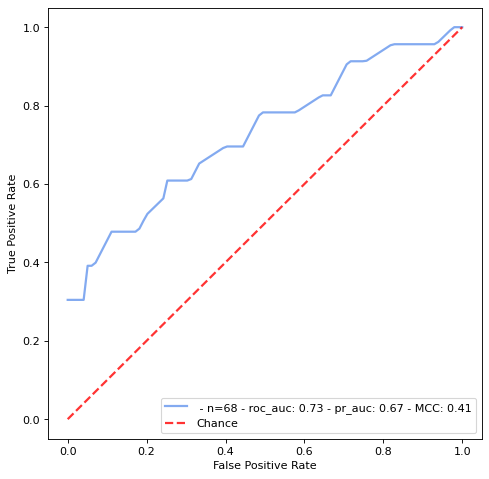

In [109]:
tmp = ML_Class.plot_roc_curve([df_pred])

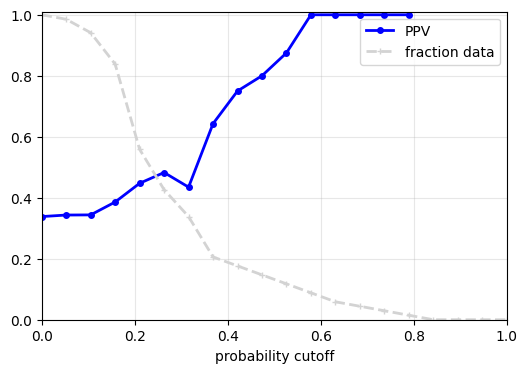

In [93]:
## get PPV from probas
ppv_df = ML_Class.get_PPV_vs_proba(df_pred, npts=20, plot=True)

In [70]:
## use conformal prediction to get confidence intervals for predictions:
# assign compounds randomly into train and test
train_idx = np.random.choice(ML_data.shape[0], size=int(0.7 * ML_data.shape[0]), replace=False)
test_idx = np.setdiff1d(np.arange(ML_data.shape[0]), train_idx)
train = list(ML_data.loc[train_idx, 'compound'] )
test  =  list(ML_data.loc[test_idx, 'compound'])

In [80]:
## get classifications from pred-specified train/test split
trained_model, pred_df = ML_Class.K_fold_by_defined_IDs_Classification(ML_data, 'compound', [[train,test]], model=model,
                                                                       col_to_rm=['label', 'compound','smiles'], v=True, ctf=0.5)

> dimension dataset: (68, 2056)


100%|██████████| 1/1 [00:00<00:00,  9.09it/s]

>> fold 1 - dim train: (47, 2053) - test: (21, 2053)
-----------------------------------------
> Fold 1 Accuracy: 0.76, F1: 0.44, Roc_auc: 0.73, PR_auc: 0.74
>> True negative (False negative):  14 ( 5 )
>> True positive (False positive):  2 ( 0 )

>>> Global accuracy: 0.76, F1: 0.44, ROC_AUC: 0.73, PR_AUC: 0.74


In [82]:
## get predictions with conformal prediction, from pre-specified train/test split
trained_model, pred_df_ICP = ML_Class.K_fold_by_ID_CP(ML_data, 'compound', [[train,test]], model=model,
                    get_metrics=False, col_to_rm=['label', 'compound','smiles'], v=True, ctf=0.5)

>> dim FIRST get train: 47 - test: 21
-----------------------------------------
> Fold 1 Acc(ctf=0.5): 0.71, F1(ctf=0.5): 0.25, Roc_auc: 0.67, PR_auc: 0.64,
>> True negative (False negative):  14 ( 6 )
>> True positive (False positive):  1 ( 0 )

>>> Global accuracy: 0.71, F1: 0.25, roc_auc: 0.67, PR_AUC: 0.64


In [ ]:
cred_ctf = 0.3
low_cred  = pred_df_ICP[pred_df_ICP['cred'] <  cred_ctf]
high_cred = pred_df_ICP[pred_df_ICP['cred'] >= cred_ctf]
tmp = ML_Class.plot_roc_curve(
    [low_cred, high_cred],
    l=['cred < %.2f' % cred_ctf, 'cred >= %.2f' % cred_ctf],
)